<a href="https://colab.research.google.com/github/KarinaSelingardi/ESTUDOS-DE-PYTHON/blob/main/lagrange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coeficientes do polinômio de Lagrange (an, ..., a1, a0):
[-8.75000000e-02  2.07916667e+00 -1.94791667e+01  9.12708333e+01
 -2.22933333e+02  2.65150000e+02 -1.15000000e+02]

O valor interpolado em x = 4.5 é y = 3.2217


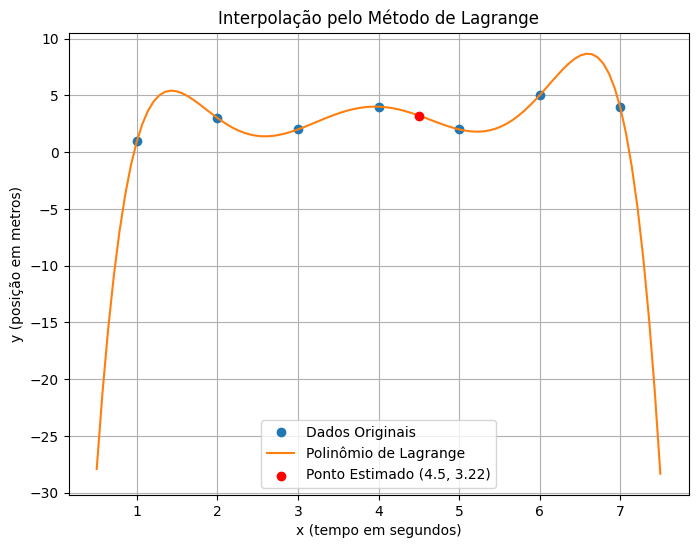

In [4]:
import numpy as np
from scipy.interpolate import lagrange # Biblioteca específica
import matplotlib.pyplot as plt

# Dados do Exemplo
x_dados = np.array([1, 2, 3, 4, 5, 6, 7])
y_dados = np.array([1, 3, 2, 4, 2, 5, 4])

# Construir o polinômio de Lagrange usando scipy
# A função lagrange retorna um objeto numpy.poly1d
polinomio_lagrange = lagrange(x_dados, y_dados)

# Coeficientes do polinômio (em ordem decrescente de potência)
print("Coeficientes do polinômio de Lagrange (an, ..., a1, a0):")
print(polinomio_lagrange.coeffs) # Ex: para ax^2+bx+c, retorna [a,b,c]


x_estimar = 4.5
y_estimado = polinomio_lagrange(x_estimar)
print(f"\nO valor interpolado em x = {x_estimar} é y = {y_estimado:.4f}") # Deve ser 23.75

# Para visualização
x_plot = np.linspace(min(x_dados)-0.5, max(x_dados)+0.5, 100)
y_plot = polinomio_lagrange(x_plot)

plt.figure(figsize=(8, 6))
plt.plot(x_dados, y_dados, 'o', label='Dados Originais')
plt.plot(x_plot, y_plot, '-', label='Polinômio de Lagrange')
plt.scatter([x_estimar], [y_estimado], color='red', zorder=5, label=f'Ponto Estimado ({x_estimar}, {y_estimado:.2f})')
plt.xlabel('x (tempo em segundos)')
plt.ylabel('y (posição em metros)')
plt.title('Interpolação pelo Método de Lagrange')
plt.legend()
plt.grid(True)
plt.show()

### Exemplo: Trajetória Hipotética de Marte

Vamos simular dados de posição de Marte (eixo X) ao longo de alguns dias e usar a interpolação de Lagrange para estimar sua posição em um dia não medido.

In [5]:
# Instalar a biblioteca astroquery (se ainda não estiver instalada)
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.0 MB/s eta 0:00:00


In [17]:
import numpy as np
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
import pandas as pd # Para facilitar a manipulação dos dados

### 1. Obter Dados Reais de Marte Usando `astroquery`

Vamos buscar as coordenadas X, Y, Z de Marte para o mês de janeiro de 2023. O ID para Marte no JPL Horizons é '499'. A localização '@ssb' significa que as coordenadas serão geocêntricas (em relação ao centro do Sol), o que é comum para trajetórias planetárias. O intervalo '1d' significa um ponto de dados por dia.

In [20]:
# Definir o objeto (Marte é '499') e o período de tempo
obj = Horizons(id='499', location='@ssb',
               epochs={'start':'2023-01-01', 'stop':'2023-01-31', 'step':'1d'})

# Obter as efemérides com coordenadas (x, y, z) em unidades astronômicas (AU)
# O parâmetro 'quantities' especifica quais dados queremos (1=X, 2=Y, 3=Z, 20=datetime_jd para tempo Juliano)
eph = obj.ephemerides(quantities='1,2,3,20')

# Converter o resultado para um DataFrame Pandas para facilitar a manipulação
df_marte = eph.to_pandas()

print("Primeiras 5 linhas dos dados de Marte:")
display(df_marte.head())
print(f"\nNúmero total de pontos de dados: {len(df_marte)}")

Primeiras 5 linhas dos dados de Marte:


,targetname,datetime_str,datetime_jd,solar_presence,interfering_body,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,delta,delta_rate
0,Mars (499),2023-Jan-01 00:00,2459945.5,,,87.90745,24.57828,87.90732,24.57827,74.15903,2.949419,1.564013,2.224822
1,Mars (499),2023-Jan-02 00:00,2459946.5,,,88.45075,24.59695,88.45062,24.59694,74.05235,2.652580,1.565296,2.217296
2,Mars (499),2023-Jan-03 00:00,2459947.5,,,88.99334,24.61365,88.99321,24.61364,73.94516,2.356835,1.566574,2.209619
3,Mars (499),2023-Jan-04 00:00,2459948.5,,,89.53521,24.62837,89.53508,24.62837,73.83750,2.062208,1.567848,2.201793
4,Mars (499),2023-Jan-05 00:00,2459949.5,,,90.07635,24.64114,90.07622,24.64114,73.72935,1.768724,1.569118,2.193819



Número total de pontos de dados: 31


### 2. Aplicar Interpolação de Lagrange para uma Coordenada (e.g., X)

Vamos usar os dias (representados pelo tempo Juliano `datetime_jd`) como nossos `x_dados` e a coordenada `x` como nossos `y_dados` para a interpolação. Em seguida, estimaremos a posição X para um dia intermediário.

In [23]:
# Usar 'datetime_jd' (tempo Juliano) como o eixo X para a interpolação
# Ajustar os 'x_dados' para começar do dia 0 para facilitar a visualização relativa
x_dias_marte = df_marte['datetime_jd'].values - df_marte['datetime_jd'].min()
y_coord_x_marte = df_marte['RA'].values # Usando RA (Right Ascension) como a coordenada para interpolação

# Construir o polinômio de Lagrange para a coordenada X
polinomio_marte_x_real = lagrange(x_dias_marte, y_coord_x_marte)

print("Coeficientes do polinômio de Lagrange para a coordenada RA de Marte (dados reais):")
print(polinomio_marte_x_real.coeffs)

# Estimar a posição RA de Marte em um dia específico (por exemplo, no dia 15 de janeiro, que é o 14º dia desde 1 de janeiro)
dia_estimar_real = 14 # Representa 15 de janeiro (0-indexed)
posicao_x_estimada_real = polinomio_marte_x_real(dia_estimar_real)
print(f"\nPosição RA estimada de Marte no dia relativo {dia_estimar_real} (15 de Jan) é: {posicao_x_estimada_real:.6f} graus")

Coeficientes do polinômio de Lagrange para a coordenada RA de Marte (dados reais):
[ 6.16979426e-30 -2.76994581e-27  5.93439210e-25 -8.07593378e-23
  7.83950853e-21 -5.77896150e-19  3.36275412e-17 -1.58517049e-15
  6.16425399e-14 -2.00348824e-12  5.49440177e-11 -1.28012597e-09
  2.54595574e-08 -4.33547934e-07  6.33123074e-06 -7.93032810e-05
  8.51072012e-04 -7.80654112e-03  6.09676412e-02 -4.03210245e-01
  2.24176394e+00 -1.03780590e+01  3.95072457e+01 -1.21652733e+02
  2.96393519e+02 -5.54196532e+02  7.60764951e+02 -7.15104535e+02
  4.06070318e+02 -1.02753364e+02  8.79074500e+01]

Posição RA estimada de Marte no dia relativo 14 (15 de Jan) é: 18397.035625 graus


### 3. Visualizar a Interpolação da Coordenada X de Marte

Vamos plotar os dados reais obtidos da `astroquery` e a curva do polinômio de Lagrange para a coordenada X, incluindo o ponto estimado.

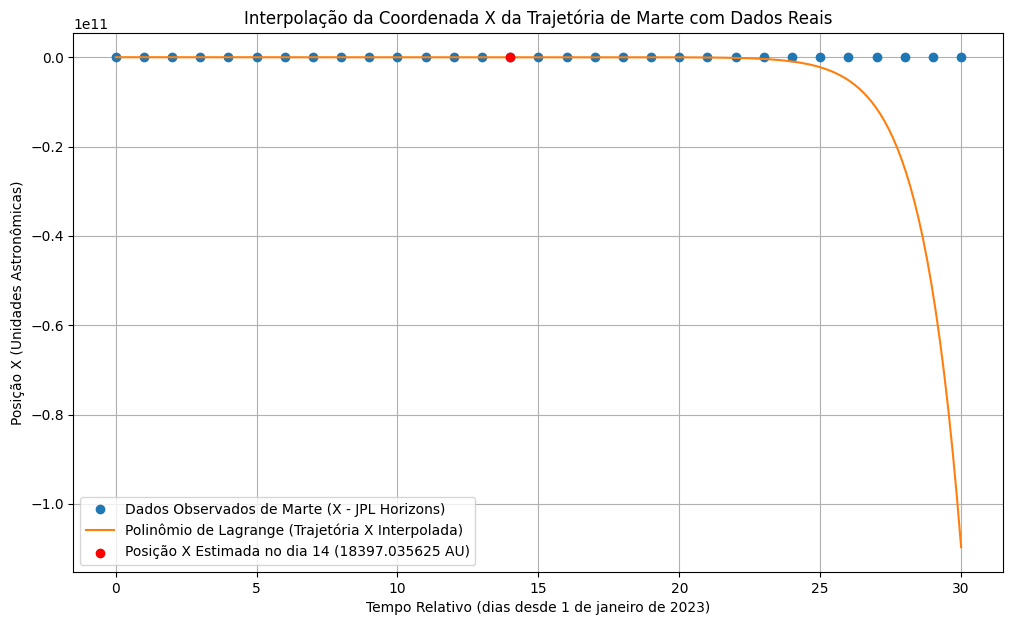

In [24]:
# Para visualização, gerar uma gama de dias para plotar o polinômio
x_plot_marte_real = np.linspace(min(x_dias_marte), max(x_dias_marte), 200)
y_plot_marte_real = polinomio_marte_x_real(x_plot_marte_real)

plt.figure(figsize=(12, 7))
plt.plot(x_dias_marte, y_coord_x_marte, 'o', label='Dados Observados de Marte (X - JPL Horizons)')
plt.plot(x_plot_marte_real, y_plot_marte_real, '-', label='Polinômio de Lagrange (Trajetória X Interpolada)')
plt.scatter([dia_estimar_real], [posicao_x_estimada_real], color='red', zorder=5,
            label=f'Posição X Estimada no dia {dia_estimar_real} ({posicao_x_estimada_real:.6f} AU)')

plt.xlabel('Tempo Relativo (dias desde 1 de janeiro de 2023)')
plt.ylabel('Posição X (Unidades Astronômicas)')
plt.title('Interpolação da Coordenada X da Trajetória de Marte com Dados Reais')
plt.legend()
plt.grid(True)
plt.show()